# Search for Supermassive Binary Black Holes Systems: A brief presentation of the new methodology

## Introduction

This work is based on <a href="#ref1">[1]</a> as part of my bachelor's thesis. In that work, singular spectrum analysis (SSA) is employed for the first time on data from the Fermi-LAT Space Telescope to study periodicities on the light curves of several blazars. The aim of using SSA is to isolate the periodic behaviour of the emissions from long-term trends and noise, and then compute the Lomb-Scargle periodogram (LSP) on the isolated oscillatory component to determine the most significant periods.
As a result, 46 blazars are identified as potential candidates for quasi-periodic oscillations (QPOs), which provides a foundation for future investigations on the detection of binary supermas
sive black hole (SMBHs) systems.

Here, some alternatives are presented to try to get more evidence on the previous results. Blazar PG1553+113 will be used as sample since it is the same one used on <a href="#ref1">[1]</a>. The first task is importing the functions we will be using and getting the light curve (LC) data. 

In [1]:
import pandas as pd
import numpy as np
from ftperiodogram.modeler import FastTemplatePeriodogram, FastMultiTemplatePeriodogram, TemplateModel
from ftperiodogram.template import Template
import matplotlib.pyplot as plt
from blazar_tools import GetLCRData, plot_analysis, time_splits, plot_split_pgram, SSA, SSA_pyts, mjd_to_year, year_to_mjd, Periodogram
from blazar_tools import LC_sim, features_extraction

from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import precision_recall_curve, roc_curve,roc_auc_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
path = 'enlacesCurvas.txt'
blazar = 'PG1553+113'
LCR_data = GetLCRData(path)
df_data= LCR_data.df_dict[blazar]
df_data.head()

,t_met,flux,flux_error,t_mjd,t_year
0,240883201.0,7.220000e-08,6.800000e-09,54698.000012,2008.635181
1,243475201.0,5.090000e-08,6.500000e-09,54728.000012,2008.717317
2,248659201.0,6.970000e-08,7.500000e-09,54788.000012,2008.881588
3,251251201.0,6.180000e-08,6.200000e-09,54818.000012,2008.963724
4,253843201.0,4.160000e-08,5.800000e-09,54848.000012,2009.045859


# 1. Current methodology

### Singular spectrum analysis

The SSA is a powerful technique for time series analysis with multiple applications in mathematics, physics or economics. The method consists in two main stages: decomposition of the series into its components, and reconstruction to separate long term trends and noise from the oscillatory components. 

We have implemented an algorithm to do that for us. In the decompostion stage of the signal, the only parameter we need to set is the window lenght $L$, which is an integer such that $2 \leq L \leq N/2$, being $N$ the number of components of the time series. This parameter sets how the time series is embeded into a multidimensional series with vectors of lenght $L$. If the time series contains a periodic component with an integer period it is recommended to set the window length proportional to that period. A window lenght fullfiling these conditions that works well is $L = 0.4 N$.

The decomposition is performed as follows:

In [3]:
flux = df_data.flux.values
t_mjd = df_data.t_mjd.values

n = len(flux)
L = int(0.4 * n) # L must be an integer

ssa = SSA(t_mjd, flux, L)

The next step is reconstruction. After the decompostion, we can asses the quality of the separation of signal and noise components by observing the correlations among the different components. SSA presents the components sorting them by importance. This importance is measured from their eigenvalues during the decomposition process. Therefore, we will have a look to the first 10 more important components and their correlations. 

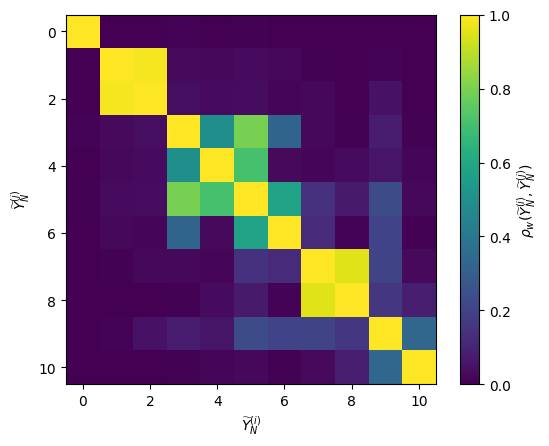

In [4]:
ssa.plot_wcorr(max = 10)

TThe correlation is measured from 0 to 1, being 1 the self correlation, and therefore a value present in the diagonal. As a first approximation, there is a clear division between three groups: 
- Component 0, which is the slowest varying component. This will be the trend.
- Components 1 and 2, which are the next most significant group of components. These will form the oscillatory component.
- The rest of the components are less important and will be treated as noise. 

Following this pipeline, an automatic reconstruction algorithm is defined which groups the most correlated components from the begining as the oscillatory component, then groups all the previous components as trend, an the rest as noise. 

In [5]:
df_ssa = ssa.auto_reconstruction()
df_ssa.head()

,trend,oscillatory,noise
54698.000012,4.210185e-08,8.343866e-09,2.171057e-08
54728.000012,4.215216e-08,7.029499e-09,1.738321e-09
54788.000012,4.219041e-08,5.407917e-09,2.213768e-08
54818.000012,4.211442e-08,3.326786e-09,1.630067e-08
54848.000012,4.207137e-08,1.043195e-09,-1.486441e-09


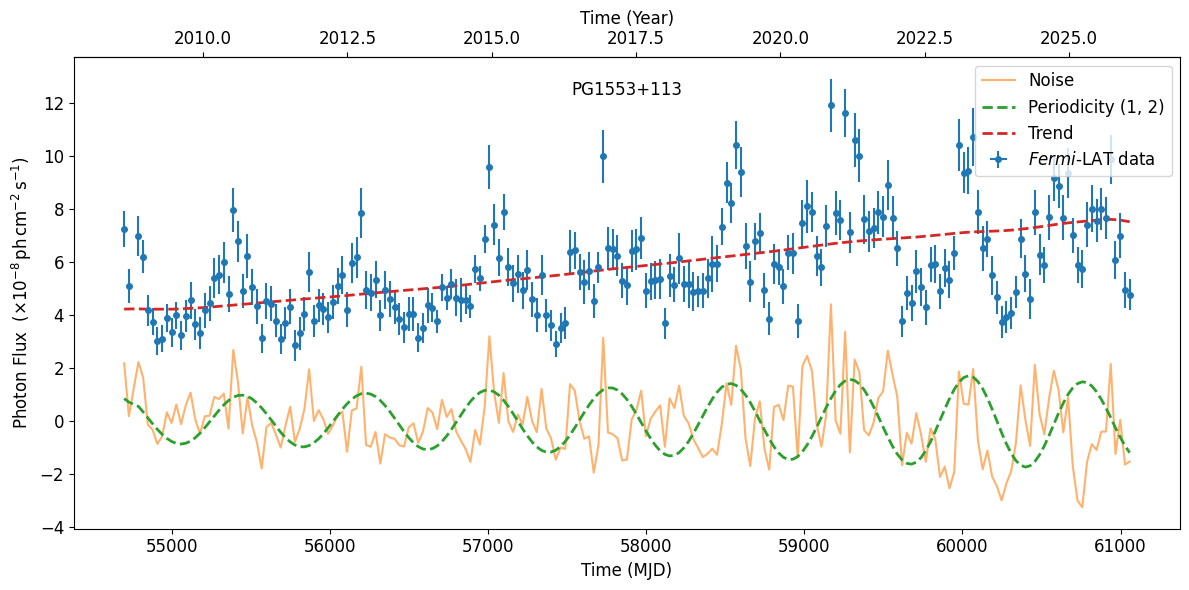

In [6]:
plot_analysis(df_data, df_ssa, blazar)

###  Lomb-Scargle periodogram

LSP is based on perfmoring a least sequare fitting of sinusoidal function to a given data. The power of each period is related to how good the fit is using a sinusoidal function of that frequency. The result is the so called periodogram, which represents the power of each fitted period. 
The detected period will be taken as the period corresponding to the peak of the periodogram and its uncertainty will be the FWHM of the gaussian function that best fits the peak. The LSP is performed for the oscillatory component only.

Full LSP Period detected: 2.09 +- 0.23 yr


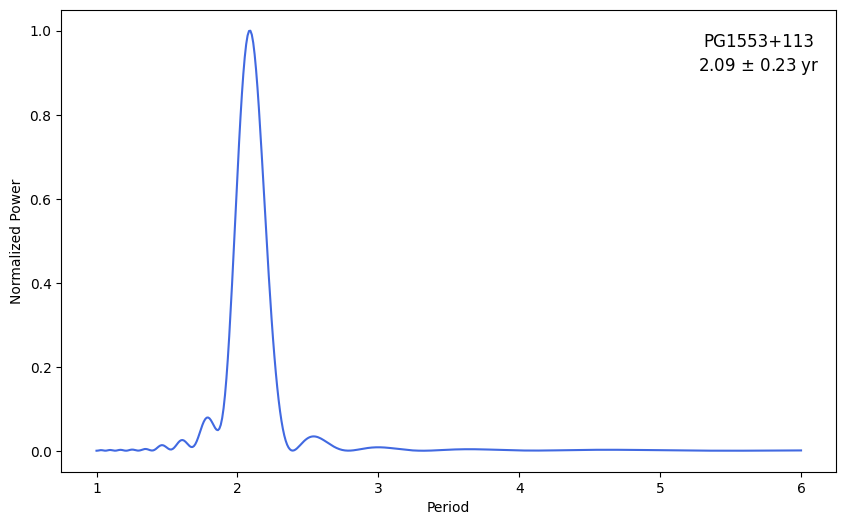

In [7]:
per = Periodogram(df_ssa, blazar)
pgram_dict = per.LSP()

## 2. New methodologies

### Time splits test

A way of testing the persistence of the periodic oscillations is splitting the LC data in two halves and then appliying the same pipeline. This is: SSA and LSP on each half. The periodicity persists if the period detected in both halves, within a reasonable tolerance.

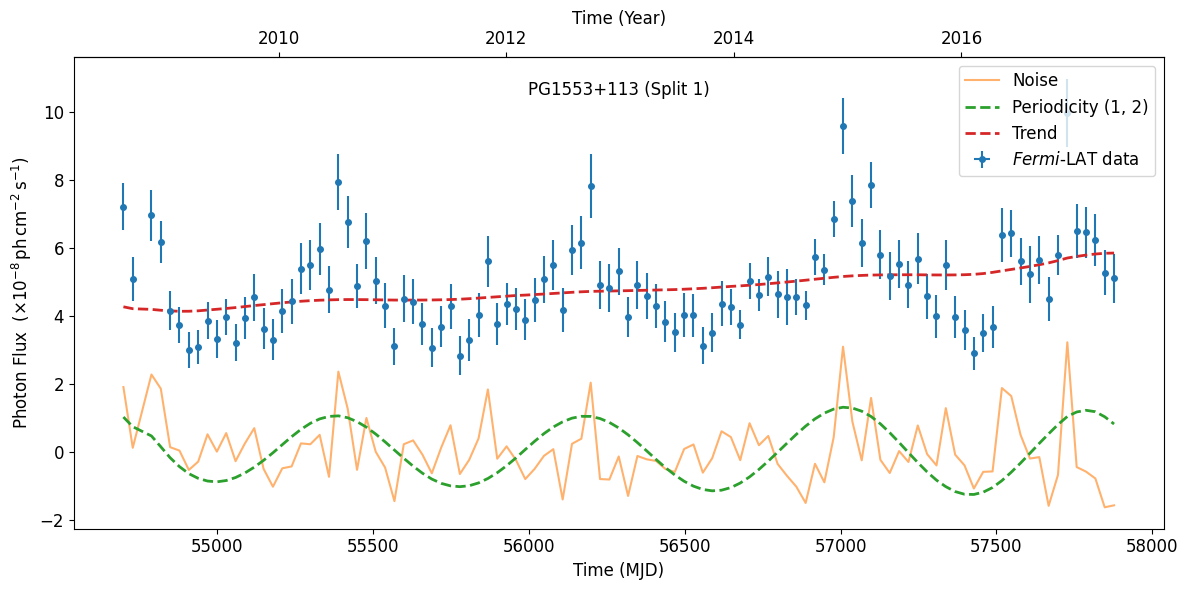

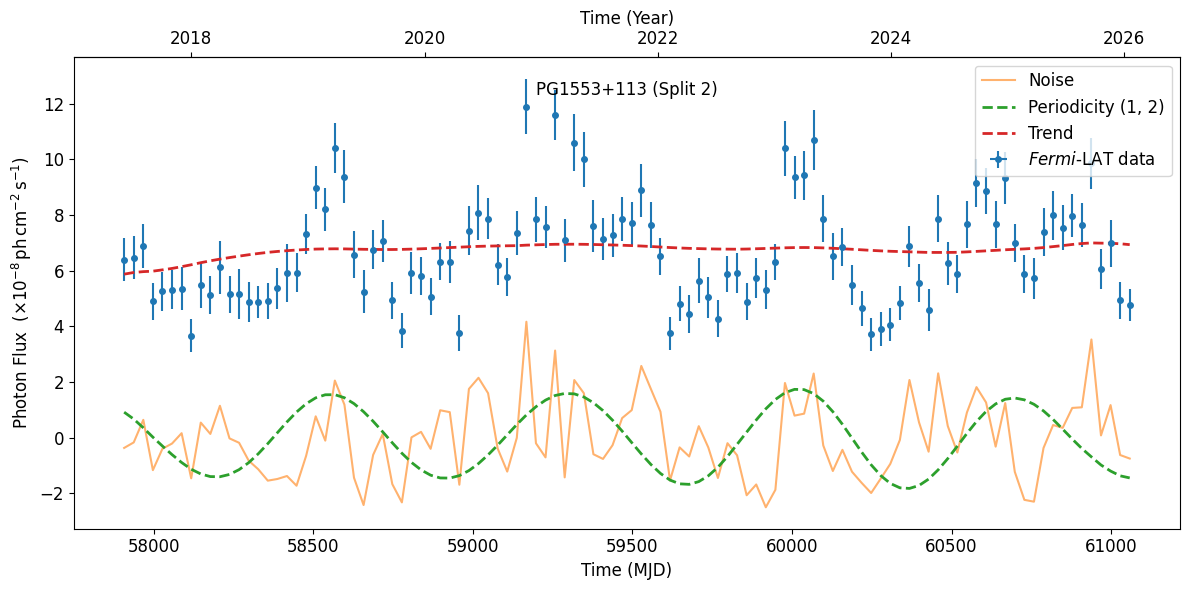

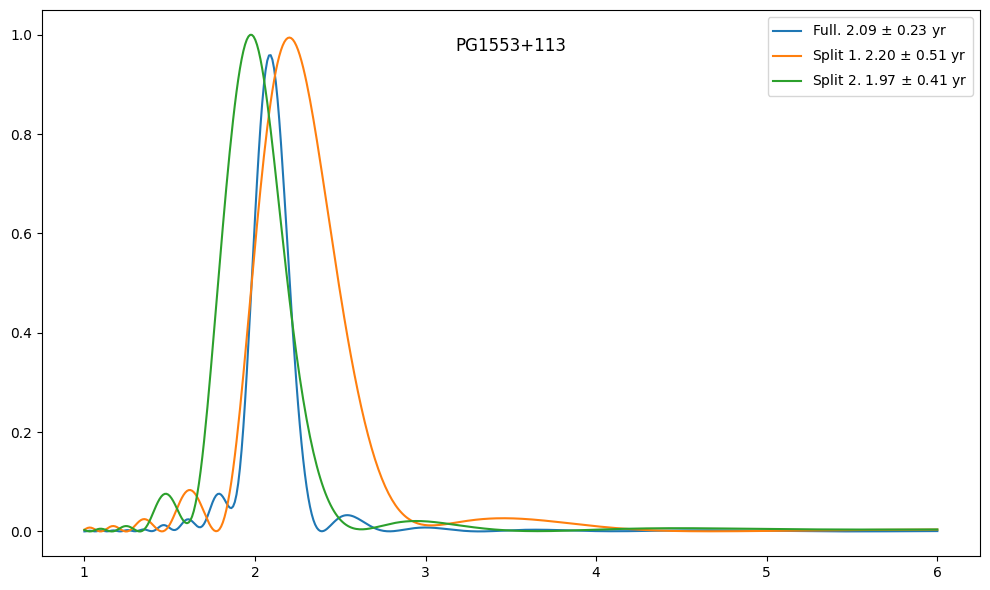

In [8]:
splits = 2
overlap = 0
df_list = time_splits(df_data, splits =2, overlap = overlap)

LSP_list = [pgram_dict]
for i in range(splits):
    split = i+1
    df = df_list[i]
    # SSA and LSP periodogram
    time_mjd_split = df.t_mjd.values
    flux_split = df.flux.values
    
    L = int(0.4*len(time_mjd_split))
    ssa = SSA(time_mjd_split, flux_split, L)
    df_ssa_split = ssa.auto_reconstruction()
    plot_analysis(df, df_ssa_split, blazar, split = split)
    
    per = Periodogram(df_ssa_split, blazar, split = split)
    LSP_result = per.LSP(plot=False)
    LSP_list.append(LSP_result)

plot_split_pgram(LSP_list, blazar)


### Deeper into SSA reconstruction

The algorith previously used works but only consider one pair to form the oscillatory component. This approximation may not be enough in many cases since relevant information about the oscillation could be cathegorized as noise. 
A different approach in the reconstruction step suggests considering how the different components evolve in time, instead of using correlations. Under this perspective, a new classification method is applied, by setting a lower frequency bound and a parameter for frequency contribution. The periodogram is computed for each component. Then:

- If its power is concentrated towards the lower frequency region, under the bound, such that its contribution in that region is greater than the parameter we set, that component will be consider as trend.
- If its power is concentrated towards the higher region of the periodogram, or is not evenly distributed, such that less than parameter we set is contained in the first half of the periodogram, that component will be considered as noise.
- The rest of the components will be considered as oscillatory.



In [9]:
freq_bound = 0.03
c_bound = 0.92
df_ssa_pyts = SSA_pyts(t_mjd, flux, L, freq_bound = freq_bound, c_bound = c_bound)

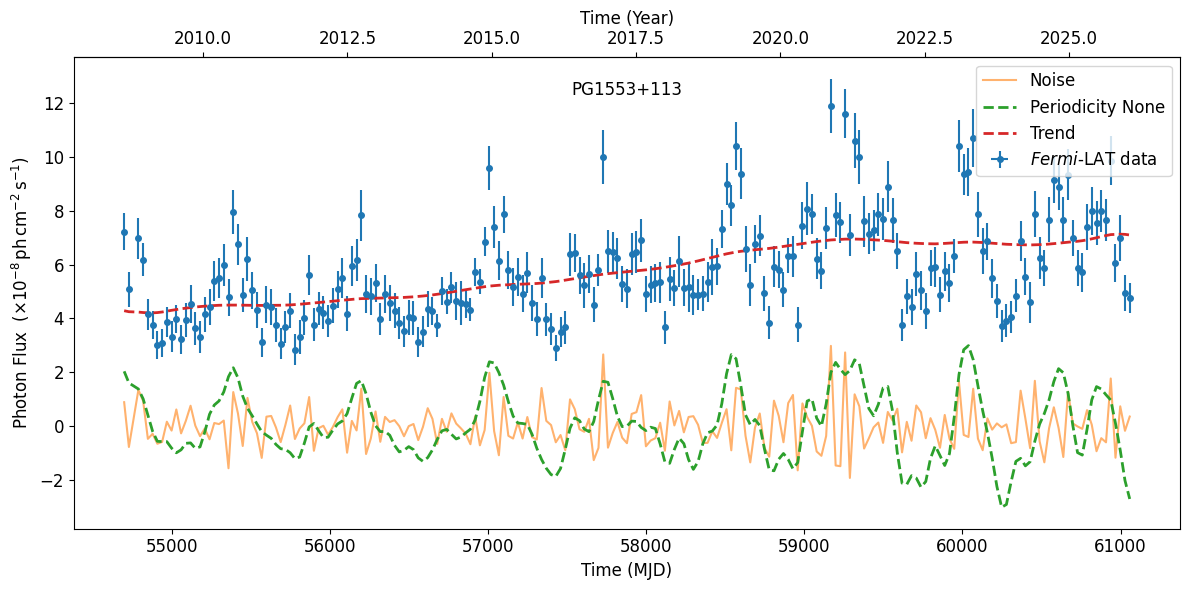

In [10]:
plot_analysis(df_data, df_ssa_pyts, blazar)

The same flow is applied now. This is, computing the LSP and then comparing the result with the oone obtained for the splits.

 Split 2 LSP Period detected: 1.97 +- 0.41 yr


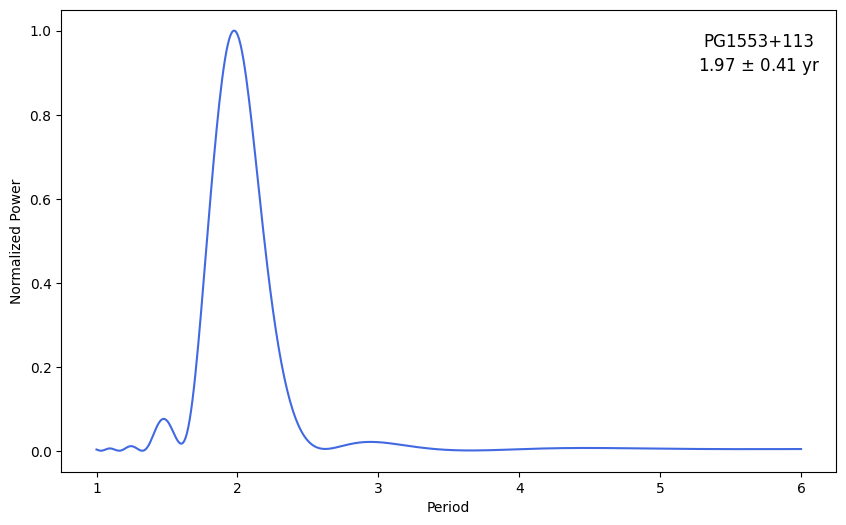

In [11]:
per_pyts = Periodogram(df_ssa_pyts, blazar)
pgram_dict_pyts = per.LSP()

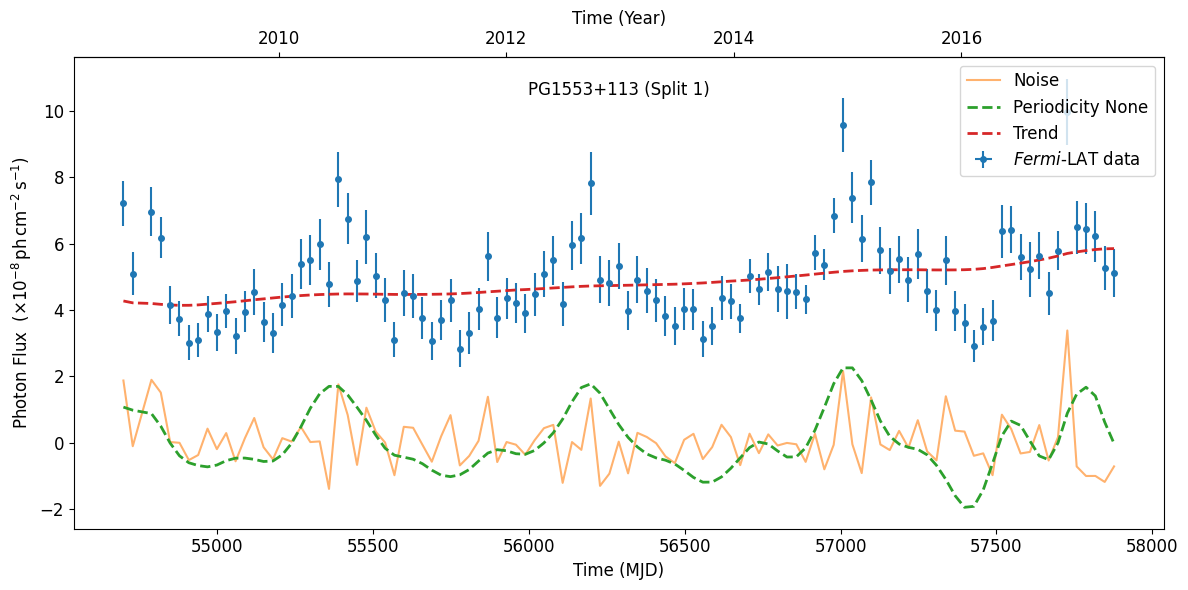

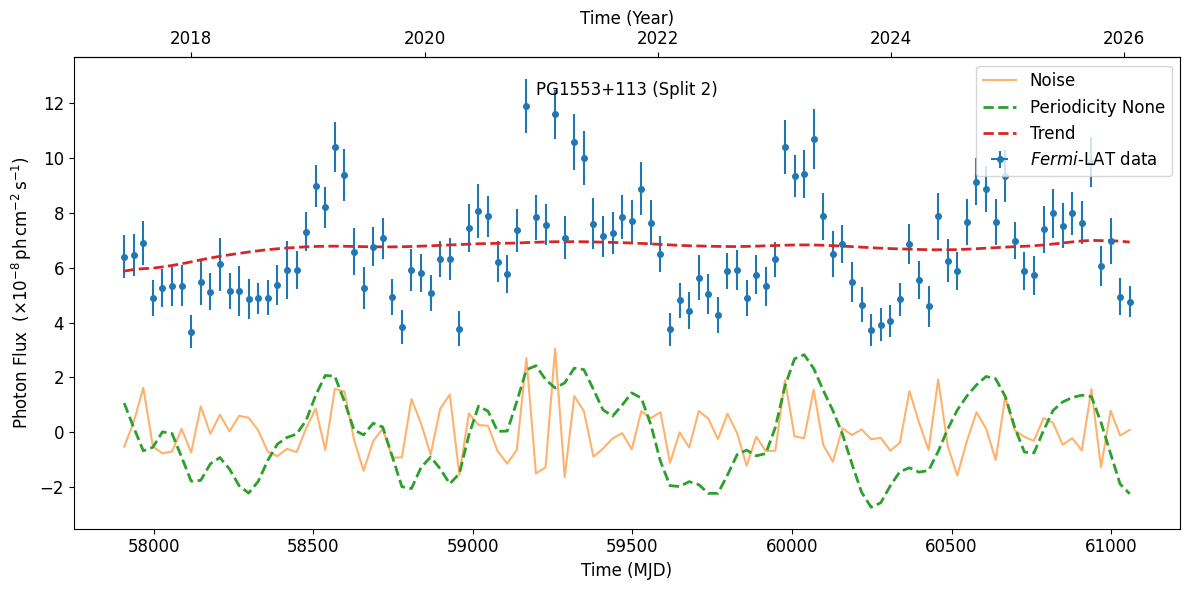

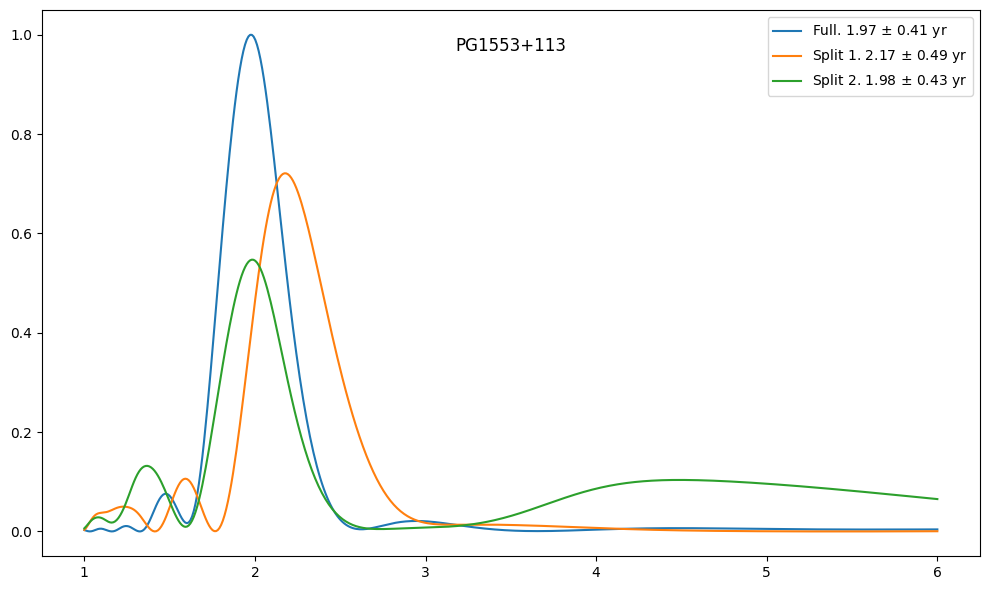

In [12]:
splits = 2
overlap = 0
df_list_pyts = time_splits(df_data, splits =2, overlap = overlap)

LSP_list_pyts = [pgram_dict_pyts]
for i in range(splits):
    split = i+1
    df = df_list_pyts[i]
    # SSA and LSP periodogram
    time_mjd_split = df.t_mjd.values
    flux_split = df.flux.values
    L = int(0.4*len(time_mjd_split))
    df_ssa_split = SSA_pyts(time_mjd_split, flux_split, L, 
                            freq_bound = freq_bound, c_bound = c_bound)
    plot_analysis(df, df_ssa_split, blazar, split = split)
    
    per = Periodogram(df_ssa_split, blazar, split = split)
    LSP_result = per.LSP(plot=False)
    LSP_list_pyts.append(LSP_result)

plot_split_pgram(LSP_list_pyts, blazar)

### Fast Template Periodogram: a first aplication in the search of blazar's periodicities

As explaine before, to computation of the LSP is based on fitting a sinusoidal function. The advantange of FTP is that this method allows any other pre defined function as a template. Since PG 1553+113 is a very good sample of regular oscillations, we can define a sample from this LC and try to fit it to other blazars. If the behaviour is the same, the attempt to fit this template will be succesful. We will use the oscillatory component from the previous SSA as the template.

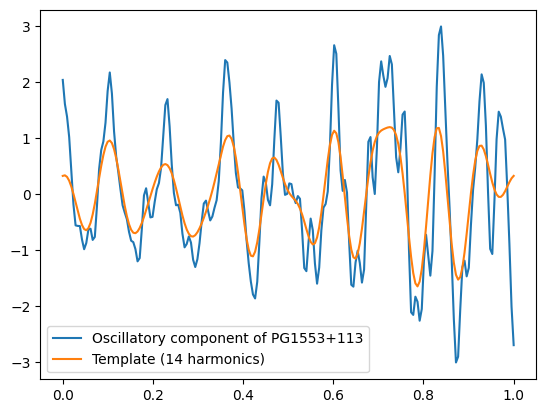

In [13]:
time = df_ssa_pyts.index.values
flux = df_ssa_pyts.oscillatory.values / 1e-8

x = np.linspace(0, 1, len(flux))
nharmonics = 14
template = Template.from_sampled(flux, nharmonics= nharmonics, template_id = f'PG1553 Template')
plt.plot(x,flux, label = 'Oscillatory component of PG1553+113')
plt.plot(x,template(x), label = f'Template ({nharmonics} harmonics)')
plt.legend()
plt.show()

This template should fit quite well on PG 1553+113, since in has been defined from itself. Therefore, the detected period should be tha same that was computed from LSP. Let us do the test.

Full FTP PG1553 Template Period detected: 2.02 +- 0.27 yr


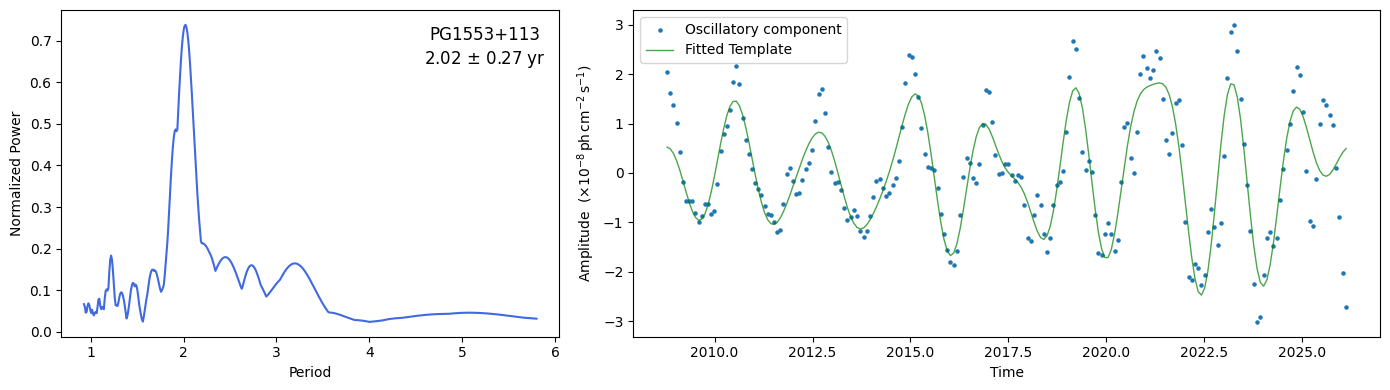

In [14]:
per = Periodogram(df_ssa_pyts, blazar)
pgram_dict_full = per.FTP(template)

Also, we expect the same result with the time split test.

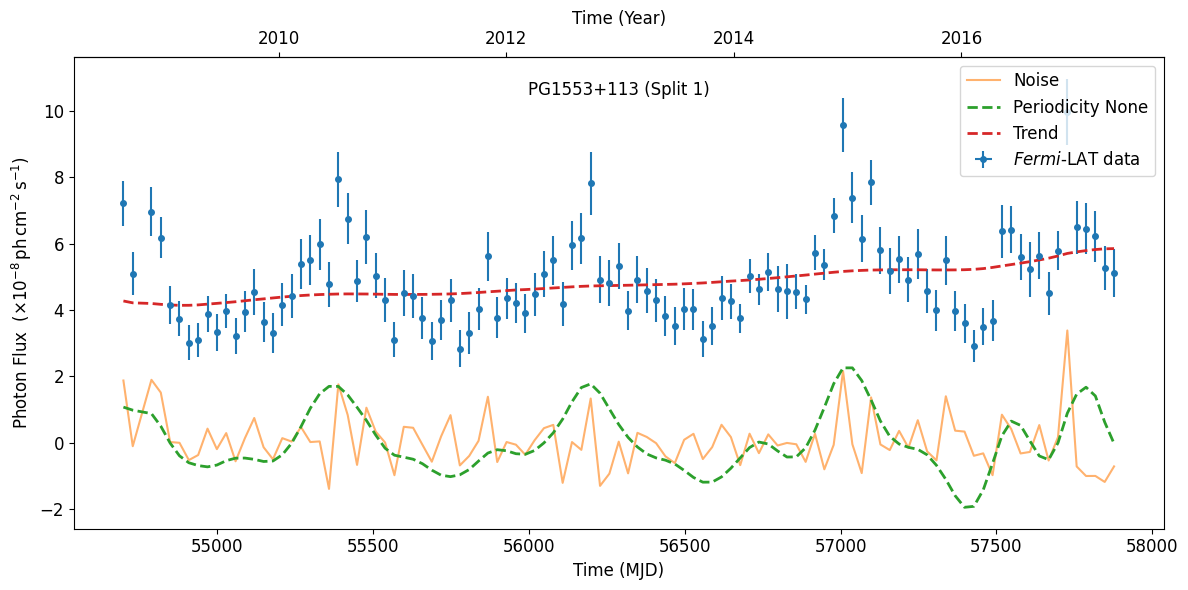

FTP PG1553 Template Split: 1 Period detected: 2.02 +- 0.43 yr


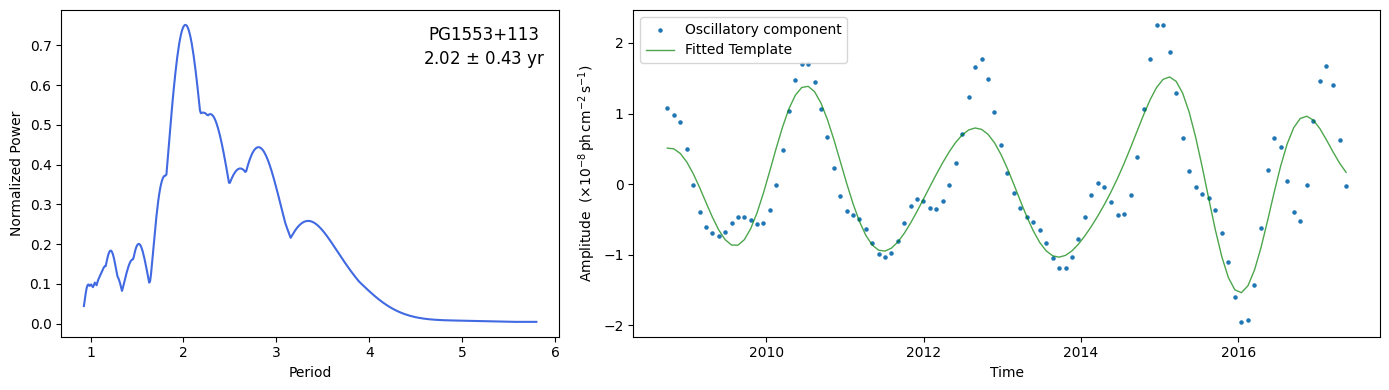

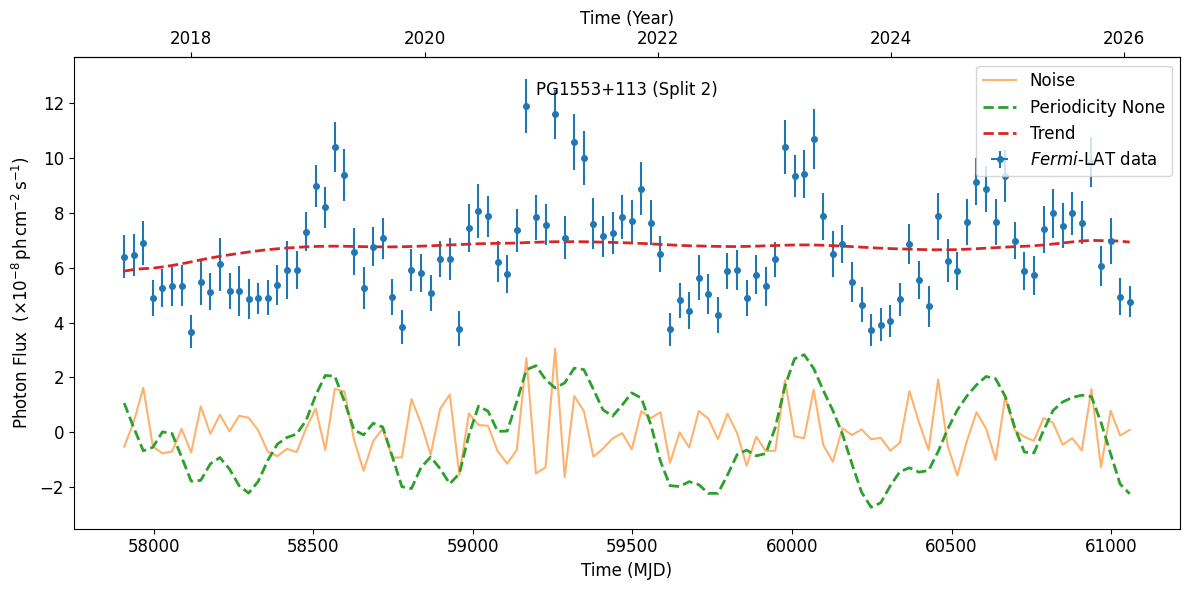

FTP PG1553 Template Split: 2 Period detected: 2.01 +- 0.57 yr


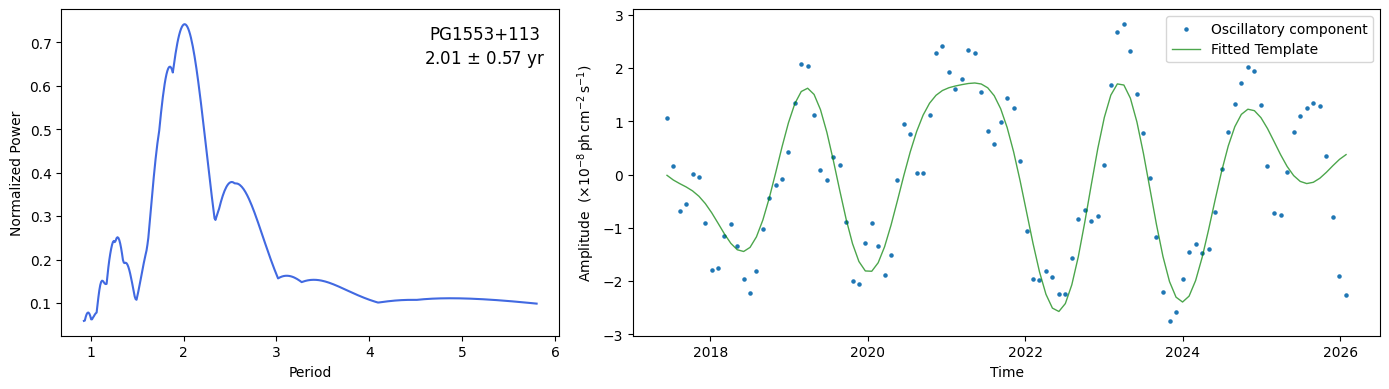

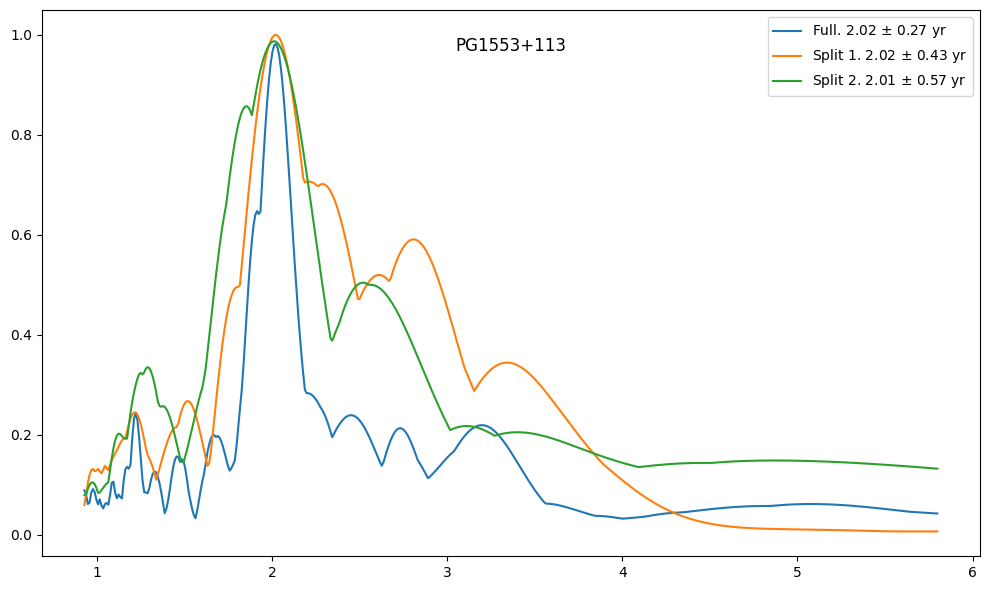

In [15]:
splits = 2
df_list_pyts = time_splits(df_data, splits =2)

freq_bound = 0.03
c_bound = 0.92

LSP_list_pyts = [pgram_dict_full]
for i in range(splits):
    split = i+1
    df = df_list_pyts[i]
    # SSA and LSP periodogram
    time_mjd_split = df.t_mjd.values
    flux_split = df.flux.values
    L = int(0.4*len(time_mjd_split))
    df_ssa_split = SSA_pyts(time_mjd_split, flux_split, L, 
                            freq_bound = freq_bound, c_bound = c_bound)
    plot_analysis(df, df_ssa_split, blazar, split = split)
    
    per = Periodogram(df_ssa_split, blazar, split = split)
    LSP_result = per.FTP(template)
    LSP_list_pyts.append(LSP_result)

plot_split_pgram(LSP_list_pyts, blazar)

This method is applied to other candidates for QPOs (e.g. PKS2155-304), and similar results from the ones of <a href="#ref1">[1]</a> are found.

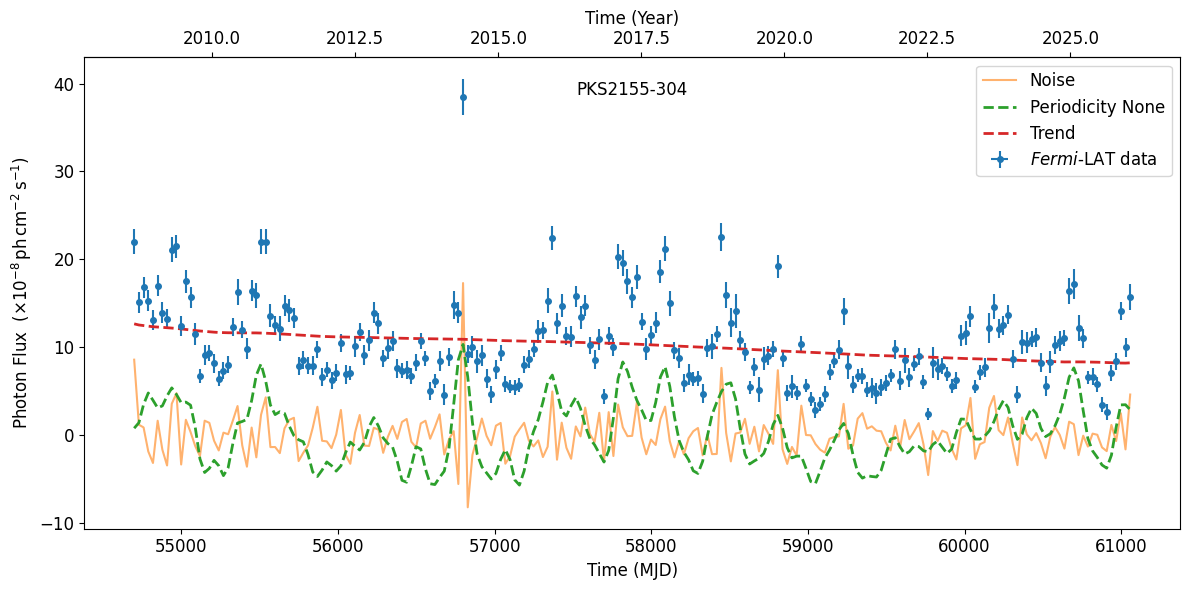

Full FTP PG1553 Template Period detected: 1.63 +- 0.29 yr


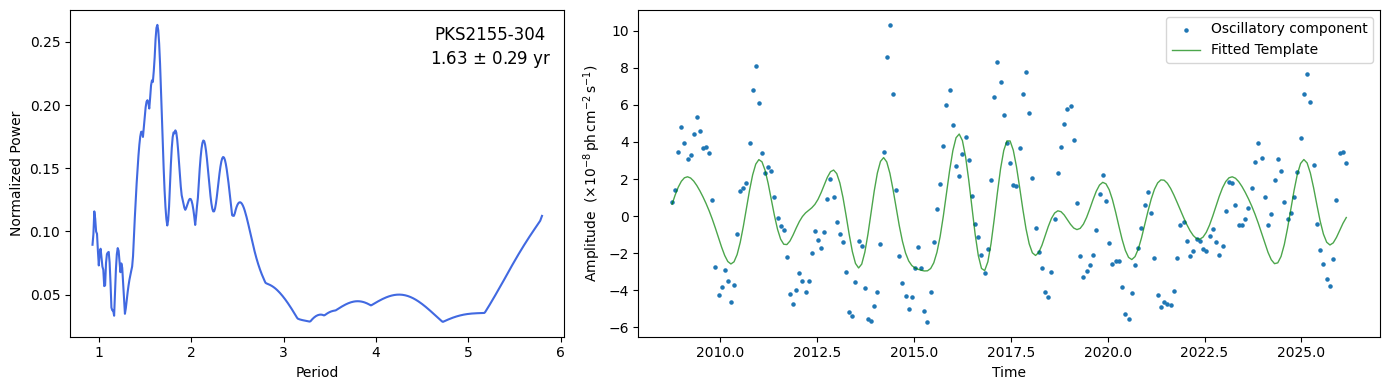

In [16]:
blazar = 'PKS2155-304'
df_data= LCR_data.df_dict[blazar]
if 'upper_limits' in df_data.columns:
    df_data['flux_ssa'] = df_data[['flux', 'upper_limits']].sum(axis=1).values
else:
    df_data['flux_ssa'] = df_data.flux
    

# Full SSA and LSP periodogram
time_mjd = df_data.t_mjd.values
flux_ssa = df_data.flux_ssa.values
L = int(0.4*len(time_mjd))
df_ssa = SSA_pyts(time_mjd, flux_ssa, L, freq_bound = freq_bound, c_bound = c_bound)

plot_analysis(df_data, df_ssa, blazar)
per = Periodogram(df_ssa, blazar)
pgram_dict_full = per.FTP(template)

## 3. Machine Learning applied to periodicity detection

Blazar emission is dominated by red noise. This noise is characterized by random emission that translates into random peaks in the periodogram. In <a href="#ref1">[1]</a>, the significance is the parameter used to confirm whether the detected period was artificially created by stochastic noise or by a real physical oscillation. Low significance means that a peak in the periodogram is likely to be just a random effect. Thus, the peaks on the periodogram of real periodicities must have high significances. In the original work, significance is determined by statistical calculations on simulated LCs that use the same parameters as the original blazar. 
A new perspective on this task is to develop a machine learning model and train it with data from several simulated LCs, some of them embedding a real periodic component and some containing noise only. 

### LC simulation and feature selection

The simulated LCs are based on a real periodic component and red noise of the same amplitude. The simulation follows the methodology described in <a href="#ref1">[1]</a>. From now on, LCs embedding a periodic component are labelled as 1, whereas those containing noise only are labelled as 0.

[]

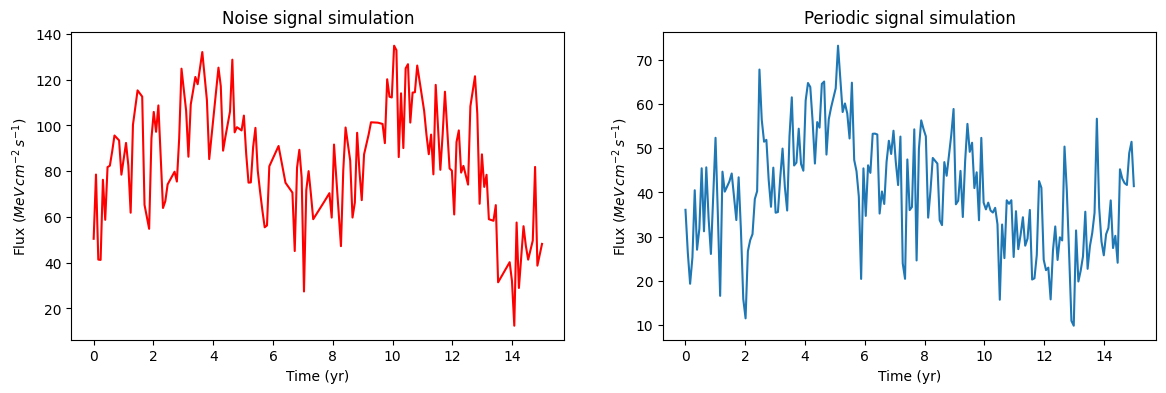

In [2]:
sim = LC_sim(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14,4))

time, flux = sim.noise()
ax1.plot(time, flux, c = 'r')
ax1.set_xlabel('Time (yr)')
ax1.set_ylabel(r'Flux $(MeV \, cm^{-2} \, s^{-1})$')
ax1.set_title('Noise signal simulation')

time, flux = sim.curve()
ax2.plot(time, flux)
ax2.set_xlabel('Time (yr)')
ax2.set_ylabel(r'Flux $(MeV \, cm^{-2} \, s^{-1})$')
ax2.set_title('Periodic signal simulation')

plt.plot()

Now, we must identify the features to choose for training the model, while taking care to avoid any data leakage. In order to avoid any change of units, since the simulated LCs are computed in different units from the units reported in the Fermi-LAT LCR (energy flux vs photon flux), every feature selected is adimensional. For the simulated LCs we perform SSA and get:

- Ratio between the standard deviation of the signal and the standard deviation of the oscillatory component
- Ratio between the standard deviation of the signal and the standard deviation of the noise component (SNR)
- Period detected
- Periodogram peak power
- Periodogram peak FWHM
- Relative difference between the periods detected in the splits with respect to the period detected on the full signal
- Relative difference between the FWHM of the peak detected in the splits with respect to the FWHM of the peak detected on the full signal
- Standard deviation of the periodogram
- Ratio between the standard deviation of the periodogram and the standard deviation of the signal
- Autocorrelation of the oscillatory component





### Random forest as model

A Random Forest is based on multiple decision trees, which are among the most powerful machine learning algorithms available today. They can be used for both classification and regression tasks. Decision trees are a type of supervised learning method consisting of a root node, branches, internal nodes, and leaf nodes. Based on the available features, an evaluation is conducted at every node to split the data into subsets until the leaf nodes are reached. These leaf nodes represent all possible outcomes within the dataset. The performance of a decision tree is determined by how the available features are used when splitting a node. 


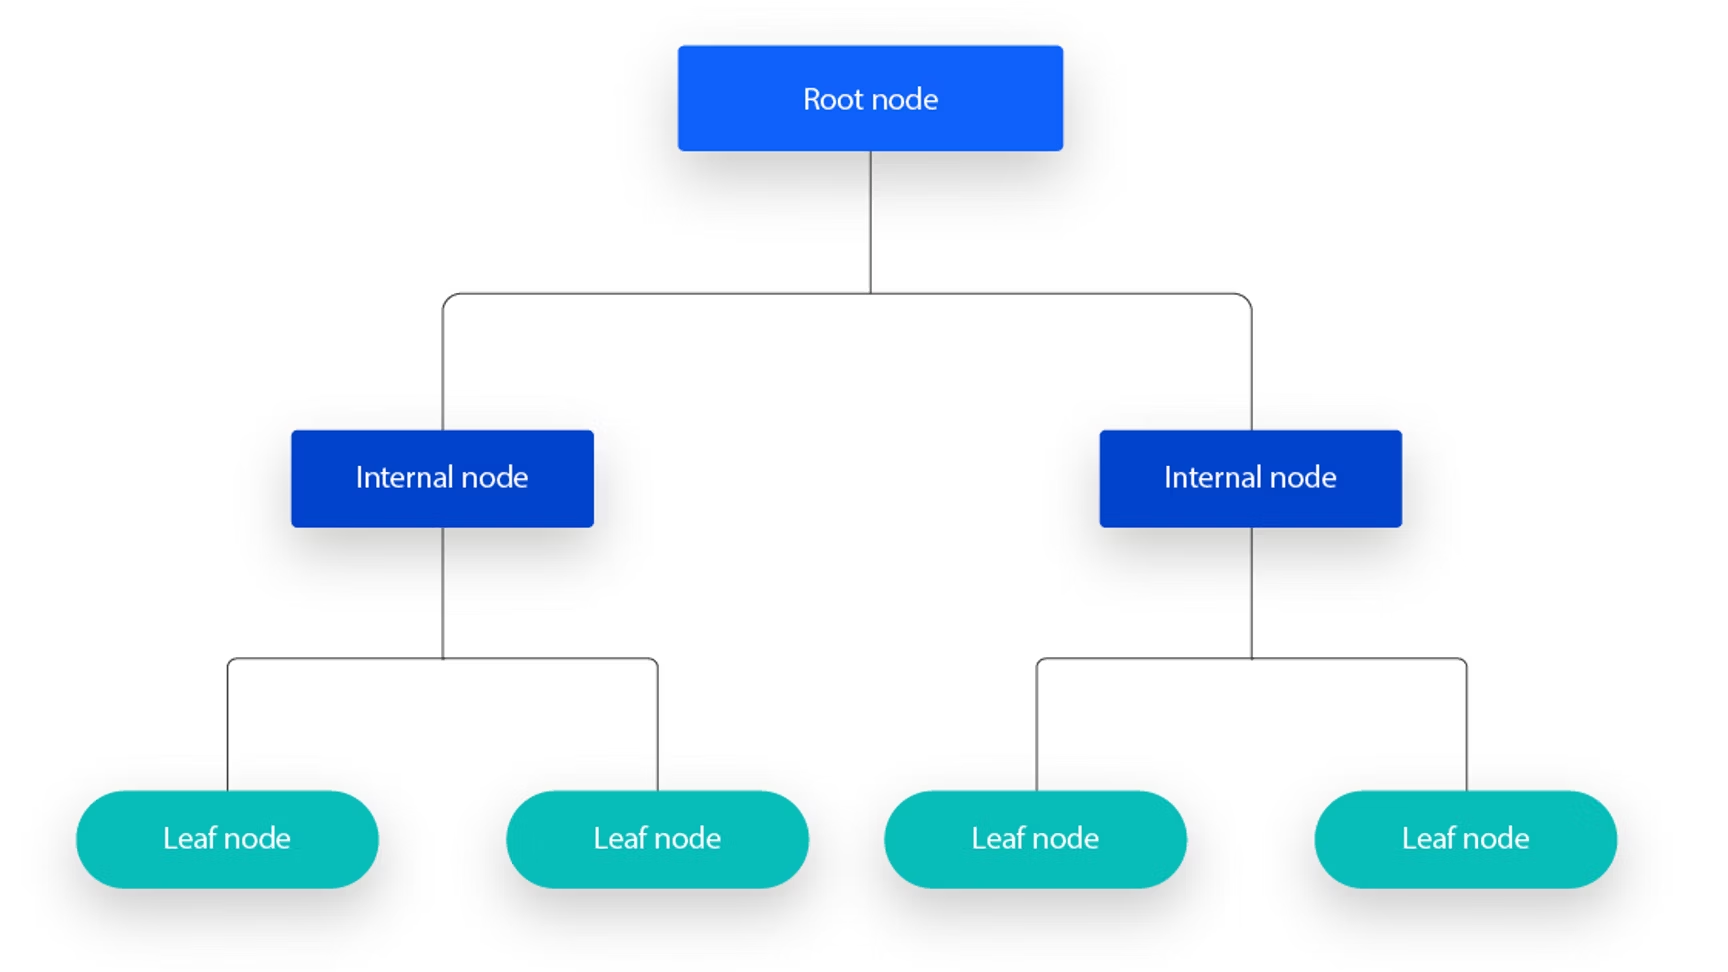

The random forest is an ensemble of the best decision trees, each one of them using a different subset of the features. This results in a greater tree diversity and richer overall choices. Finally, the decission of the forest is based on majority voting among all of the available trees. If most of the trees determine that the signal contains a periodic component, this will give the predicition of the forest. This vote counting gives the probability of a prediction. 

The main parameters we can control for a random forest are:
- The number of trees
- The maximum depth of each tree
- The maximum number of features to consider when looking for the best split

Among many others. The best prediction is obtained by finding an equilibrium of these parameters. For this analysis, we have found a balance between good results and computational efficiency using 200 estimators (trees), Gini impurity to measure the quality of the splits, the maximum number of features as the square root of the total number of features, and not setting a maximum depth for the trees. 

In [3]:
forest_clf = RandomForestClassifier(n_estimators=200, random_state=42)

### Training the model

A number of 10000 LCs are simulated to train the model, half of them cointaining a periodic component. For each one of them we computed the features needed for the model, and then the data is splitted in two pieces: one subset will be used to fit the model (train), and the other remainder will be hidden for the model and finalle will be used as validation data (test). A total of 80% of the data will be used for training, and the remainder 20% for testing.

In [7]:
n_simulations = 25 # Test on 25 
freq_bound = 0.028
c_bound = 0.9

sim = LC_sim(17)
features_list = [] # This list will store the features of each simulation

blazar = 'sim'
for i in range(n_simulations):

    # Smulations containing a periodic component
    time, curve = sim.curve()
    features_curve= features_extraction(time, curve, freq_bound, c_bound)
    features_curve['class'] = 1
    features_list.append(features_curve)

    # Simulations containing noise only
    time, noise= sim.noise()
    features_noise= features_extraction(time, noise, freq_bound, c_bound)
    features_noise['class'] = 0
    features_list.append(features_noise)

df_features_sim = pd.DataFrame(features_list) # Final df containing the information of every simulation
df_features_sim.head() 

The gaussian fit for the peak does not converge


,r_std,SNR,period,fwhm,peak_power,r_period_splits,r_fwhm_splits,r_period_fwhm,r_power_fwhm,std_pgram,autocorrelation,class
0,1.565070,1.715660,1.140281,0.072844,21.652471,0.008787,0.152271,15.653792,297.245507,0.003092,0.290436,1
1,2.242463,1.658099,1.370741,0.094463,7.735578,0.372807,2.408217,14.510833,81.889756,0.002499,0.279474,0
2,1.450807,2.159720,5.629259,1.395249,5.110001,0.089000,0.170921,4.034590,3.662429,0.004366,0.142231,1
3,3.379072,2.456232,3.254509,0.652279,4.719308,0.332512,NaN,4.989440,7.235100,0.002612,0.094762,0
4,1.648716,2.242085,4.066132,0.993285,2.879131,0.391819,1.054173,4.093619,2.898594,0.004652,0.266987,1


In [5]:
df_features = df_features_sim.dropna()
X = df_features.drop(columns = ['class'] ) # X contains the known features of experimental data
y = df_features['class'] # y is the target (0 or 1)
train_X, val_X, train_y, val_y =  train_test_split(X, y, train_size = 0.8, random_state= 42)

# Training
forest_clf.fit(train_X, train_y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Evaluation of the performance of the model

...

## References

<a name="ref1">[1]</a> A. Rico et al., «Singular spectrum analysis of Fermi-LAT blazar light curves: A systematic search for periodicity and trends in the time domain», A&A, vol. 697, p. A35, may 2025, doi: 10.1051/0004-6361/202452495.


